In [1]:
from langchain_core.documents import Document

In [2]:
from importlib import metadata
from langchain_core.documents import Document
doc = Document(
    page_content = "This is a normal document i have created to study the document loaders in langchain",
    metadata = {
        "source" : "felx.com",
        "pages" : 1,
        "author" : "Sukesh S T",
        "date_created" : "2026-06-14"
    }
)
doc

Document(metadata={'source': 'felx.com', 'pages': 1, 'author': 'Sukesh S T', 'date_created': '2026-06-14'}, page_content='This is a normal document i have created to study the document loaders in langchain')

In [3]:
import os 
os.makedirs("../data/text_files", exist_ok=True)

In [4]:
sample_texts={
    "../data/text_files/python_intro.txt":"""Python Programming Introduction

Python is a high-level, interpreted programming language known for its simplicity and readability.
Created by Guido van Rossum and first released in 1991, Python has become one of the most popular
programming languages in the world.

Key Features:
- Easy to learn and use
- Extensive standard library
- Cross-platform compatibility
- Strong community support

Python is widely used in web development, data science, artificial intelligence, and automation.""",
    
    "../data/text_files/machine_learning.txt": """Machine Learning Basics

Machine learning is a subset of artificial intelligence that enables systems to learn and improve
from experience without being explicitly programmed. It focuses on developing computer programs
that can access data and use it to learn for themselves.

Types of Machine Learning:
1. Supervised Learning: Learning with labeled data
2. Unsupervised Learning: Finding patterns in unlabeled data
3. Reinforcement Learning: Learning through rewards and penalties

Applications include image recognition, speech processing, and recommendation systems
    
    
    """

}
for filepath, content in sample_texts.items():
    with open(filepath, 'w', encoding="utf-8") as f:
        f.write(content)

print("done")

done


In [5]:
# Use the updated community package for document loaders
from langchain_community.document_loaders import TextLoader

# Initialize the loader with your file path and encoding
loader = TextLoader("../data/text_files/python_intro.txt", encoding="utf-8")

# Load the file into a list of Document objects
document = loader.load()

# Print the loaded content
print(document)


/tmp/ipykernel_15208/943976761.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import TextLoader
/run/media/stsukesh/crucail1tb/KrishNaikCourse/RAG/.venv/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[Document(metadata={'source': '../data/text_files/python_intro.txt'}, page_content='Python Programming Introduction\n\nPython is a high-level, interpreted programming language known for its simplicity and readability.\nCreated by Guido van Rossum and first released in 1991, Python has become one of the most popular\nprogramming languages in the world.\n\nKey Features:\n- Easy to learn and use\n- Extensive standard library\n- Cross-platform compatibility\n- Strong community support\n\nPython is widely used in web development, data science, artificial intelligence, and automation.')]


In [6]:

### Directory Loader
from langchain_community.document_loaders import DirectoryLoader

## load all the text files from the directory
dir_loader=DirectoryLoader(
    "../data/text_files",
    glob="**/*.txt", ## Pattern to match files  
    loader_cls= TextLoader, ##loader class to use
    loader_kwargs={'encoding': 'utf-8'},
    show_progress=True)

documents=dir_loader.load()
documents

100%|██████████| 2/2 [00:00<00:00, 2042.51it/s]


[Document(metadata={'source': '../data/text_files/machine_learning.txt'}, page_content='Machine Learning Basics\n\nMachine learning is a subset of artificial intelligence that enables systems to learn and improve\nfrom experience without being explicitly programmed. It focuses on developing computer programs\nthat can access data and use it to learn for themselves.\n\nTypes of Machine Learning:\n1. Supervised Learning: Learning with labeled data\n2. Unsupervised Learning: Finding patterns in unlabeled data\n3. Reinforcement Learning: Learning through rewards and penalties\n\nApplications include image recognition, speech processing, and recommendation systems\n\n\n    '),
 Document(metadata={'source': '../data/text_files/python_intro.txt'}, page_content='Python Programming Introduction\n\nPython is a high-level, interpreted programming language known for its simplicity and readability.\nCreated by Guido van Rossum and first released in 1991, Python has become one of the most popular\np

In [7]:

from langchain_community.document_loaders import PyPDFLoader, PyMuPDFLoader

## load all the text files from the directory
dir_loader=DirectoryLoader(
    "../data/pdf_files",
    glob="**/*.pdf", ## Pattern to match files  
    loader_cls= PyMuPDFLoader, ##loader class to use
    show_progress=True

)

pdf_documents=dir_loader.load()
pdf_documents

100%|██████████| 7/7 [00:00<00:00, 15.88it/s]


[Document(metadata={'producer': 'Adobe PDF Library 16.0.7', 'creator': 'Adobe InDesign 17.3 (Windows)', 'creationdate': '2022-08-08T12:07:29-05:00', 'source': '../data/pdf_files/anti-corruption-policy.pdf', 'file_path': '../data/pdf_files/anti-corruption-policy.pdf', 'total_pages': 11, 'format': 'PDF 1.7', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2022-08-08T12:07:29-05:00', 'trapped': '', 'modDate': "D:20220808120729-05'00'", 'creationDate': "D:20220808120729-05'00'", 'page': 0}, page_content='Flex  \nAnti-Corruption Policy\n \n \n \nAt Flex, we take compliance and ethics seriously. That is why our Code of Business Conduct and \nEthics is so important to the Company and our employees. Following the law and operating with \nintegrity is a core part of who we are.\nThis Anti-Corruption Policy (“Policy”) reiterates our commitment to integrity and explains the specific \nrequirements and prohibitions applicable to our operations under anti-corruption laws world

In [8]:
type(pdf_documents[0
                   ])

langchain_core.documents.base.Document

In [9]:
# pip install curl_cffi
from curl_cffi import requests
from langchain_core.documents import Document

def load_with_impersonation(url):
    # impersonate="chrome" fakes the network signature of a real browser
    response = requests.get(url, impersonate="chrome")
    
    if response.status_code == 200:
        return Document(
            page_content=response.text,
            metadata={"source": url}
        )
    else:
        print(f"Failed with status: {response.status_code}")

url = "https://www.ambitionbox.com/reviews/flex-hr-policies-reviews-7687?page=1"
doc = load_with_impersonation(url)


Document(metadata={'source': 'https://www.ambitionbox.com/reviews/flex-hr-policies-reviews-7687?page=1'}, page_content='<!DOCTYPE html><html><head><meta charSet="utf-8"/><title>Flex HR Policies Reviews by 50+ Employees | AmbitionBox</title><meta name="title" content="Flex HR Policies Reviews by 50+ Employees | AmbitionBox"/><meta name="description" content="Flex HR Policies Reviews by current and past employees about ✓salary &amp; benefits ✓work culture ✓skill development ✓career growth ✓job security ✓work-life balance and more. Read more about working at Flex HR Policies."/><meta name="viewport" content="width=device-width,initial-scale=1, minimum-scale=1, interactive-widget=resizes-content"/><link rel="icon" type="image/png" sizes="16x16" href="https://static.ambitionbox.com/alpha/img/supporting-images/browser_icon_16x16.png"/><link rel="icon" type="image/png" sizes="32x32" href="https://static.ambitionbox.com/alpha/img/supporting-images/browser_icon_32x32.png"/><link rel="icon" type
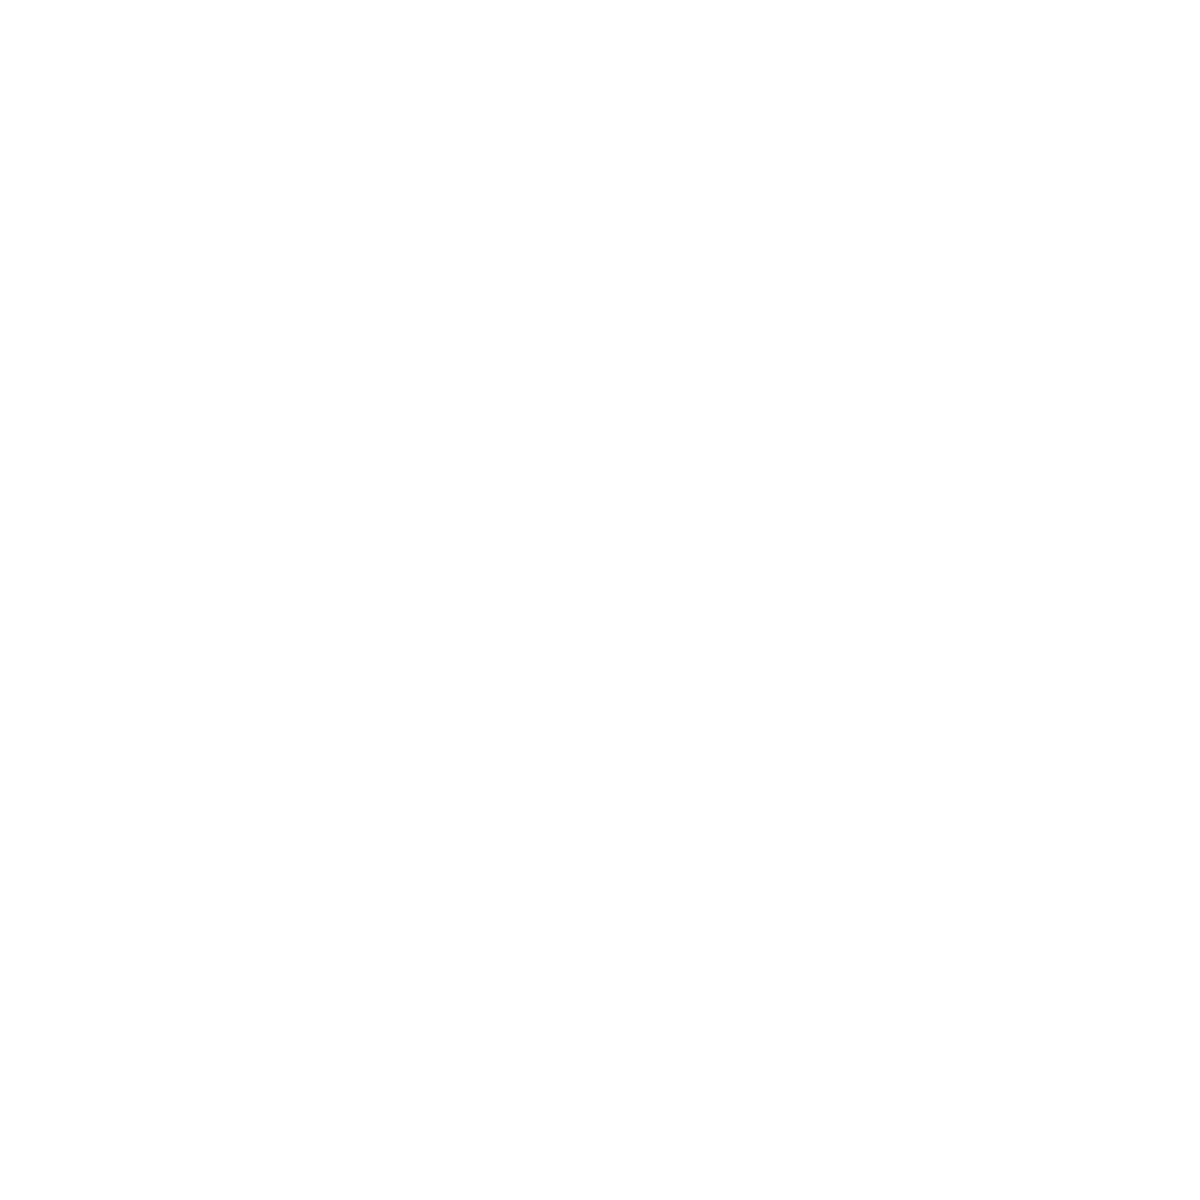

In [10]:
doc

# Document -> Chunks

In [11]:
### Text splitting get into chunks

def split_documents(documents,chunk_size=1000,chunk_overlap=200):
    """Split documents into smaller chunks for better RAG performance"""
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        length_function=len,
        separators=["\n\n", "\n", " ", ""]
    )
    split_docs = text_splitter.split_documents(documents)
    print(f"Split {len(documents)} documents into {len(split_docs)} chunks")
    
    # Show example of a chunk
    if split_docs:
        print(f"\nExample chunk:")
        print(f"Content: {split_docs[0].page_content[:200]}...")
        print(f"Metadata: {split_docs[0].metadata}")
    
    return split_docs

In [12]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
chunks=split_documents(pdf_documents)
chunks

Split 42 documents into 141 chunks

Example chunk:
Content: Flex  
Anti-Corruption Policy
 
 
 
At Flex, we take compliance and ethics seriously. That is why our Code of Business Conduct and 
Ethics is so important to the Company and our employees. Following t...
Metadata: {'producer': 'Adobe PDF Library 16.0.7', 'creator': 'Adobe InDesign 17.3 (Windows)', 'creationdate': '2022-08-08T12:07:29-05:00', 'source': '../data/pdf_files/anti-corruption-policy.pdf', 'file_path': '../data/pdf_files/anti-corruption-policy.pdf', 'total_pages': 11, 'format': 'PDF 1.7', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2022-08-08T12:07:29-05:00', 'trapped': '', 'modDate': "D:20220808120729-05'00'", 'creationDate': "D:20220808120729-05'00'", 'page': 0}


[Document(metadata={'producer': 'Adobe PDF Library 16.0.7', 'creator': 'Adobe InDesign 17.3 (Windows)', 'creationdate': '2022-08-08T12:07:29-05:00', 'source': '../data/pdf_files/anti-corruption-policy.pdf', 'file_path': '../data/pdf_files/anti-corruption-policy.pdf', 'total_pages': 11, 'format': 'PDF 1.7', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2022-08-08T12:07:29-05:00', 'trapped': '', 'modDate': "D:20220808120729-05'00'", 'creationDate': "D:20220808120729-05'00'", 'page': 0}, page_content='Flex  \nAnti-Corruption Policy\n \n \n \nAt Flex, we take compliance and ethics seriously. That is why our Code of Business Conduct and \nEthics is so important to the Company and our employees. Following the law and operating with \nintegrity is a core part of who we are.\nThis Anti-Corruption Policy (“Policy”) reiterates our commitment to integrity and explains the specific \nrequirements and prohibitions applicable to our operations under anti-corruption laws world

In [13]:
! uv add langchain-text-splitters


Resolved 222 packages in 1ms
Checked 219 packages in 26ms


# Embedding and VectorDB

In [14]:
import numpy as np
import os

from sentence_transformers import SentenceTransformer
import chromadb
from chromadb.config import Settings
import uuid
from typing import List, Dict, Any, Tuple
from sklearn.metrics.pairwise import cosine_similarity

In [18]:
class EmbeddingManager:
    """Handles document embedding generation using SentenceTransformer"""
    
    def __init__(self, model_name: str = "BAAI/bge-small-en-v1.5"):
        """
        Initialize the embedding manager
        
        Args:
            model_name: HuggingFace model name for sentence embeddings
        """
        self.model_name = model_name
        self.model = None
        self._load_model()

    def _load_model(self):
        """Load the SentenceTransformer model"""
        try:
            print(f"Loading embedding model: {self.model_name}")
            self.model = SentenceTransformer(self.model_name)
            print(f"Model loaded successfully. Embedding dimension: {self.model.get_sentence_embedding_dimension()}")
        except Exception as e:
            print(f"Error loading model {self.model_name}: {e}")
            raise

    def generate_embeddings(self, texts: List[str]) -> np.ndarray:
        """
        Generate embeddings for a list of texts
        
        Args:
            texts: List of text strings to embed
            
        Returns:
            numpy array of embeddings with shape (len(texts), embedding_dim)
        """
        if not self.model:
            raise ValueError("Model not loaded")
        
        print(f"Generating embeddings for {len(texts)} texts...")
        embeddings = self.model.encode(texts, show_progress_bar=True)
        print(f"Generated embeddings with shape: {embeddings.shape}")
        return embeddings


## initialize the embedding manager

embedding_manager=EmbeddingManager()
embedding_manager

Loading embedding model: BAAI/bge-small-en-v1.5


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7993.05it/s]


Model loaded successfully. Embedding dimension: 384


/tmp/ipykernel_15208/1753216108.py:20: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"Model loaded successfully. Embedding dimension: {self.model.get_sentence_embedding_dimension()}")


### VectorStore

In [20]:
class VectorStore:
    """Manages document embeddings in a ChromaDB vector store"""
    
    def __init__(self, collection_name: str = "pdf_documents", persist_directory: str = "../data/vector_store"):
        """
        Initialize the vector store
        
        Args:
            collection_name: Name of the ChromaDB collection
            persist_directory: Directory to persist the vector store
        """
        self.collection_name = collection_name
        self.persist_directory = persist_directory
        self.client = None
        self.collection = None
        self._initialize_store()

    def _initialize_store(self):
        """Initialize ChromaDB client and collection"""
        try:
            # Create persistent ChromaDB client
            os.makedirs(self.persist_directory, exist_ok=True)
            self.client = chromadb.PersistentClient(path=self.persist_directory)
            
            # Get or create collection
            self.collection = self.client.get_or_create_collection(
                name=self.collection_name,
                metadata={"description": "PDF document embeddings for RAG"}
            )
            print(f"Vector store initialized. Collection: {self.collection_name}")
            print(f"Existing documents in collection: {self.collection.count()}")
            
        except Exception as e:
            print(f"Error initializing vector store: {e}")
            raise

    def add_documents(self, documents: List[Any], embeddings: np.ndarray):
        """
        Add documents and their embeddings to the vector store
        
        Args:
            documents: List of LangChain documents
            embeddings: Corresponding embeddings for the documents
        """
        if len(documents) != len(embeddings):
            raise ValueError("Number of documents must match number of embeddings")
        
        print(f"Adding {len(documents)} documents to vector store...")
        
        # Prepare data for ChromaDB
        ids = []
        metadatas = []
        documents_text = []
        embeddings_list = []
        
        for i, (doc, embedding) in enumerate(zip(documents, embeddings)):
            # Generate unique ID
            doc_id = f"doc_{uuid.uuid4().hex[:8]}_{i}"
            ids.append(doc_id)
            
            # Prepare metadata
            metadata = dict(doc.metadata)
            metadata['doc_index'] = i
            metadata['content_length'] = len(doc.page_content)
            metadatas.append(metadata)
            
            # Document content
            documents_text.append(doc.page_content)
            
            # Embedding
            embeddings_list.append(embedding.tolist())
        
        # Add to collection
        try:
            self.collection.add(
                ids=ids,
                embeddings=embeddings_list,
                metadatas=metadatas,
                documents=documents_text
            )
            print(f"Successfully added {len(documents)} documents to vector store")
            print(f"Total documents in collection: {self.collection.count()}")
            
        except Exception as e:
            print(f"Error adding documents to vector store: {e}")
            raise

vectorstore=VectorStore()
vectorstore

Vector store initialized. Collection: pdf_documents
Existing documents in collection: 282


In [19]:
# 1. Extract texts from your document chunks
chunk_texts = [doc.page_content for doc in chunks]

# 2. Generate embeddings using your embedding manager
chunk_embeddings = embedding_manager.generate_embeddings(chunk_texts)

# 3. Add the chunks and embeddings to the vector store
vectorstore.add_documents(chunks, chunk_embeddings)


Generating embeddings for 141 texts...


Batches: 100%|██████████| 5/5 [00:00<00:00,  6.57it/s]


Generated embeddings with shape: (141, 384)
Adding 141 documents to vector store...
Successfully added 141 documents to vector store
Total documents in collection: 282
